## CausalMix validation figures

In [ ]:
from pathlib import Path
import sys

# --- Resolve repo root (works whether you run from repo root or within notebooks/) ---
REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / "src").exists():
    if (REPO_ROOT.parent / "src").exists():
        REPO_ROOT = REPO_ROOT.parent
    elif (REPO_ROOT.parent.parent / "src").exists():
        REPO_ROOT = REPO_ROOT.parent.parent

sys.path.insert(0, str(REPO_ROOT))
sys.path.insert(0, str(REPO_ROOT / "src"))

from IPython.display import display
from notebooks.set_up import (
    ensure_dirs,
    FIG_DIR,
    VALIDATION_DIR, 
    DEMO_DIR, PRIVATE_DIR, 
)

ensure_dirs()

# Inputs/outputs for CausalMix validation artifacts
output_result = str(VALIDATION_DIR) + "/"

output_figure = FIG_DIR
# For legacy code that uses string concatenation:
output_figure = str(output_figure) + "/"

# Ensure scenario subfolders exist (CausalMix saves figures using string prefixes)
from pathlib import Path as _Path
for _sub in ["m1", "m2", "m3"]:
    (VALIDATION_DIR / _sub).mkdir(parents=True, exist_ok=True)

DATA_MODE ="private"

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from typing import Dict, Optional, Union

# CausalMix + plotting utilities
from causalmix.core.causalmix import CausalMix
from causalmix.data.schema import DataSchema
from causalmix.viz.plots import single_column_plot, pair_column_plot, plot_joint_embedding_2d

# Real dataset (private) must be stored locally (not committed):
#   data/private/mcrpc_real.parquet
# For a public demo run, place a small sample under:
#   data/demo/mcrpc_real_demo.parquet

if DATA_MODE == "private":
    real_path = PRIVATE_DIR / "mcrpc_real.parquet"
elif DATA_MODE == "demo":
    real_path = DEMO_DIR / "mcrpc_real_demo.parquet"
else:
    raise ValueError("DATA_MODE must be 'private' or 'demo'.")

if not real_path.exists():
    raise FileNotFoundError(
        f"Expected dataset not found at {real_path}.\n"
        "If using demo mode, ensure the demo file is placed under data/demo/.\n"
        "If using private mode, place the confidential dataset under data/private/."
    )

mcrpc_data = pd.read_parquet(real_path)

# Variable types
numerical_var = ["age", "Charlson"]
categorical_var = mcrpc_data.select_dtypes(include=["object", "category"]).columns.to_list()
binary_var = mcrpc_data.columns.difference(categorical_var + numerical_var).to_list()
unique_levels = {col: int(mcrpc_data[col].nunique()) for col in categorical_var}

print("n rows:", len(mcrpc_data))
print("numerical:", numerical_var)
print("categorical:", categorical_var)
print("binary:", list(binary_var))


# Create plots for the CausalMix validation

In [0]:
# Optional: hardware info (safe to skip)
import os
try:
    import torch
    print("CUDA available:", torch.cuda.is_available())
    print("GPU name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")
except Exception as e:
    print("torch not available:", e)

print("CPU cores:", os.cpu_count())


CUDA available: True
GPU name: NVIDIA L40S
numer of cores: 8


In [0]:
import numpy as np
import matplotlib.pyplot as plt

def plot_marginal_panel_5x4(
    real_data: pd.DataFrame,
    synthetic_data: Union[pd.DataFrame, Dict[str, pd.DataFrame]],
    schema,
    columns: list,
    out_path: Optional[str] = None,
    sample_size: Optional[int] = None,
):
    """
    Plot up to 20 marginal distributions in a 5x4 panel and save as a single figure.

    Layout:
      - 5 rows
      - 4 columns
    """

    n_vars = len(columns)
    if n_vars > 20:
        raise ValueError("This panel is designed for up to 20 variables (5x4).")

    nrows, ncols = 5, 4

    # --- Recommended ICML-friendly size for 2-column span ---
    # ~1.1–1.2 inches per row
    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(6.8, 6.6),   # width = two columns, height tuned for 5 rows
    )
    axes = axes.flatten()

    for col, ax in zip(columns, axes):
        single_column_plot(
            real_data=real_data,
            synthetic_data=synthetic_data,
            schema=schema,
            column_name=col,
            sample_size=sample_size,
            legend_outside=False,
            show_legend=False,
            main_title=None,
            ax=ax,
            add_title=False,
            label_fontsize = 7,
            tick_fontsize=6,
            linewidth = 0.5,
        )
        #ax.set_title(col, fontsize=7) # don't need top title
        ax.tick_params(labelsize=6)

    # Turn off unused axes if <20 variables
    for ax in axes[n_vars:]:
        ax.axis("off")

    fig.tight_layout(rect=[0, 0.08, 1, 1])  # leave 10% at bottom

    # --- Single legend for entire panel ---
    handles, labels = axes[0].get_legend_handles_labels()
    # Leave space for legend
    #fig.subplots_adjust(bottom=0.12, top=0.98, wspace=0.25, hspace=0.35)
    if handles:
        fig.legend(
            handles,
            labels,
            loc="lower center",
            bbox_to_anchor=(0.5, 0.02), 
            ncol=len(labels),
            fontsize=7,
            frameon=False,
        )
    if out_path:
        fig.savefig(out_path, bbox_inches="tight")
    plt.close(fig)

    return fig

In [0]:
# Save plots for the causal fidelity across all three scenarios
## including treatment effects, unmeasured confounding, and overlap
# Scenario 1: homogeneous treatment effect, no unmeasured confounding, perfect overlap
def treatment_effect_fn(x, index):
    # X is a torch.Tensor of features excluding treatment
    return 0.1  # effect differs by the first variable (binary)

def selection_bias_fn(x, t, index):
    # latent risk constructed from observable X
    return 0

def overlap_fn(x, index):
    return 0

m1 = CausalMix(
    data = mcrpc_data,  
    post_treatment_var = ["hosp_ed_any"],  
    treatment_var = ["exp"],  
    binary_var = binary_var, 
    categorical_var = categorical_var,  
    numerical_var = numerical_var,  
    integer_var = numerical_var, 
    categorical_dims=unique_levels,      
    var_bounds={},  
)

m1.fit(
    treatment_effect_fn=treatment_effect_fn,
    selection_bias_fn=selection_bias_fn,
    overlap_target=overlap_fn,
    effect_rigidity=1e3,
    effect_mse_weight=0.3, # effect blend weight on MSE
    effect_var_weight=2e-1, # variance penalty for treatment effect residuals
    bias_rigidity=1e3,
    bias_mse_weight=0.3, # bias blend weight on MSE
    bias_var_weight=2e-2, # variance penalty for bias residuals
    overlap_weight = 1e1,
    )

# Last logged validation loss from the final epoch
last_val_X = m1.m_pre.trainer.callback_metrics.get("val_loss")
print("Last val_loss for X:", float(last_val_X) if last_val_X is not None else "N/A")
last_val_Y = m1.m_post.trainer.callback_metrics.get("val_loss")
print("Last val_loss for Y:", float(last_val_Y) if last_val_Y is not None else "N/A")

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name         ┃ Type       ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ encoder      │ Sequential │  1.2 K │ train │     0 │
│ 1 │ en_mu        │ Linear     │  1.2 K │ train │     0 │
│ 2 │ en_logvar    │ Linear     │  1.2 K │ train │     0 │
│ 3 │ decoder      │ Sequential │  1.3 K │ train │     0 │
│ 4 │ output_heads │ ModuleDict │  1.5 K │ train │     0 │
│ 5 │ var_heads    │ ModuleDict │  1.2 K │ train │     0 │
└───┴──────────────┴────────────┴────────┴───────┴───────┘

Trainable params: 7.5 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 7.5 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 48                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

/local_disk0/.ephemeral_nfs/cluster_libraries/python/lib/python3.10/site-packages/pytorch_lightning/utilities/_pytree.py:21: FutureWarning:

`isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

/local_disk0/.ephemeral_nfs/cluster_libraries/python/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: PossibleUserWarning:

The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.

/local_disk0/.ephemeral_nfs/cluster_libraries/python/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: PossibleUserWarning:

The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.

INFO:pytorc

┏━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name         ┃ Type       ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ encoder      │ Sequential │    128 │ train │     0 │
│ 1 │ en_mu        │ Linear     │    130 │ train │     0 │
│ 2 │ en_logvar    │ Linear     │    130 │ train │     0 │
│ 3 │ decoder      │ Sequential │  1.4 K │ train │     0 │
│ 4 │ output_heads │ ModuleDict │    130 │ train │     0 │
│ 5 │ var_heads    │ ModuleDict │    130 │ train │     0 │
└───┴──────────────┴────────────┴────────┴───────┴───────┘

Trainable params: 2.1 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 2.1 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 14                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

/local_disk0/.ephemeral_nfs/cluster_libraries/python/lib/python3.10/site-packages/pytorch_lightning/utilities/_pytree.py:21: FutureWarning:

`isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

/local_disk0/.ephemeral_nfs/cluster_libraries/python/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: PossibleUserWarning:

The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.

/local_disk0/.ephemeral_nfs/cluster_libraries/python/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: PossibleUserWarning:

The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.



Last val_loss for X: -0.47888094186782837
Last val_loss for Y: 0.17453914880752563


Overlap metrics: {'dec/log_ratio_mean': 0.001, 'dec/log_ratio_std': 0.007, 'dec/target_mean': 0.0, 'dec/target_std': 0.0, 'dec/mse_to_target': 0.0, 'dec/fraction_within_tol': 1.0, 'ps/auc': 0.532, 'ps/hist_overlap_coeff': 0.953, 'ps/frac_common_support': 1.0, 'ps/frac_common_support_t0': 1.0, 'ps/frac_common_support_t1': 1.0}
checking
X_np: (4098, 18)
T_np: (4098,)
tau_pred: (4098,)
kappa_pred: (4098,)
tau_target: (4098,)
kappa_target: (4098,)


/databricks/python/lib/python3.10/site-packages/scipy/stats/_stats_py.py:4424: ConstantInputWarning:

An input array is constant; the correlation coefficient is not defined.



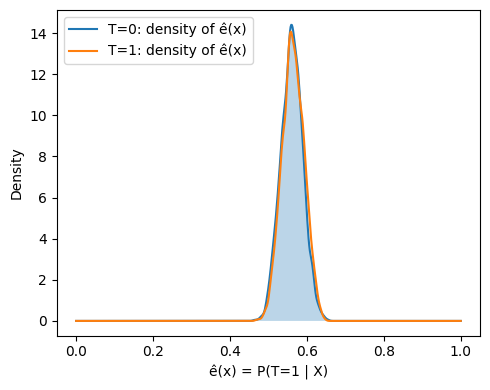

Overlap metrics: {'dec/log_ratio_mean': -0.002, 'dec/log_ratio_std': 0.01, 'dec/target_mean': 0.0, 'dec/target_std': 0.0, 'dec/mse_to_target': 0.0, 'dec/fraction_within_tol': 1.0, 'ps/auc': 0.543, 'ps/hist_overlap_coeff': 0.933, 'ps/frac_common_support': 1.0, 'ps/frac_common_support_t0': 1.0, 'ps/frac_common_support_t1': 1.0}


/databricks/python/lib/python3.10/site-packages/scipy/stats/_stats_py.py:4424: ConstantInputWarning:

An input array is constant; the correlation coefficient is not defined.



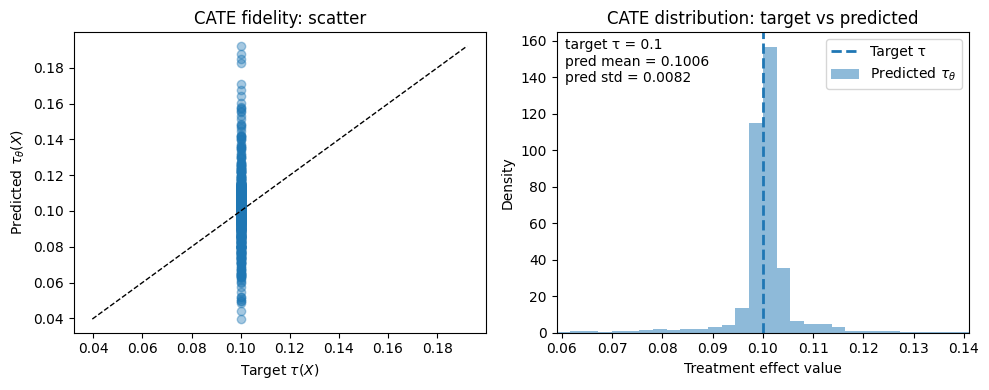

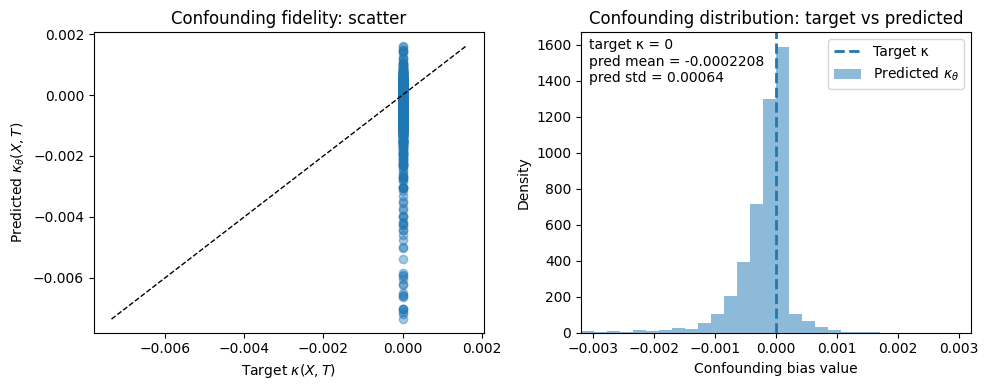

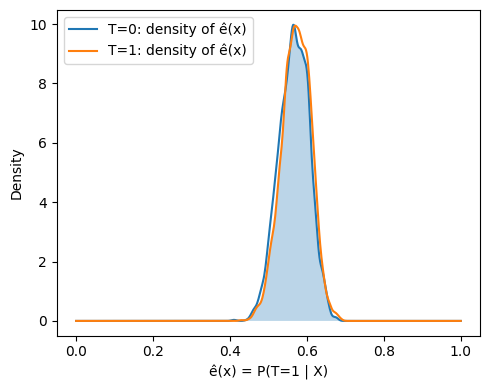

CausalEvalResults(mae_tau=0.004, corr_tau=nan, ate_pred=0.101, ate_target=0.1, ate_abs_error=0.001, tau_wasserstein=0.004, mae_kappa=0.0, mae_kappa_t0=0.0, mae_kappa_t1=0.0, kappa_wasserstein=0.0, overlap_coeff=0.954, bw0=0.02, bw1=0.02)


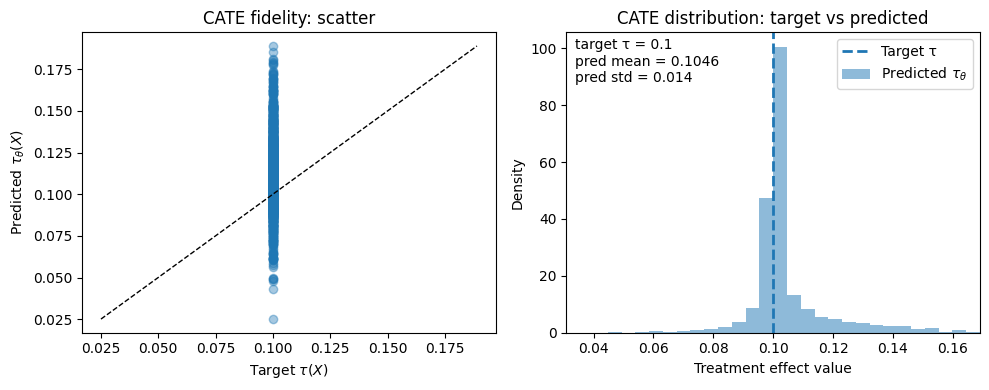

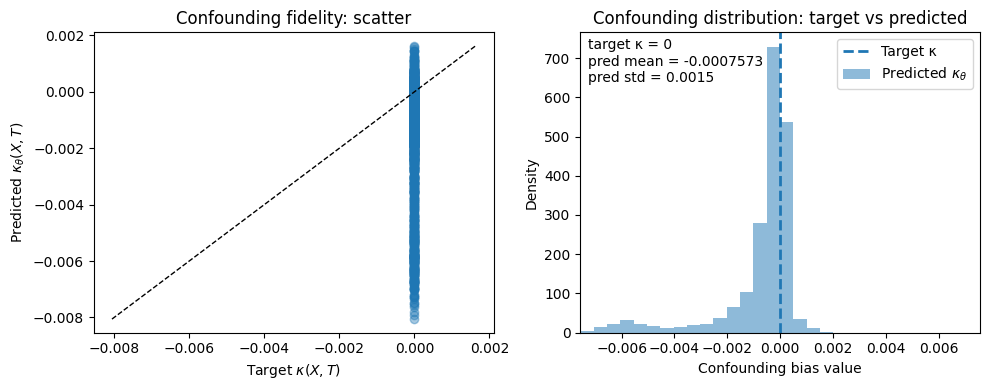

In [0]:
# Scenario 1
# generate new samples and return causal evaluation metrics
out1_bgmm = m1.causal_bgmm(
    n_samples=mcrpc_data.shape[0],
    deterministic=False,
    return_probs=False,
    plot=True,
    savepath=output_result+"m1/m1_bgmm_"
)
out1_gauss = m1.causal_gauss(
    n_samples=mcrpc_data.shape[0],
    deterministic=False,
    return_probs=False,
    plot=True,
    savepath=output_result+"m1/m1_gauss_"
)

cm_metrics = out1_bgmm["causal_metrics"]
print(cm_metrics)

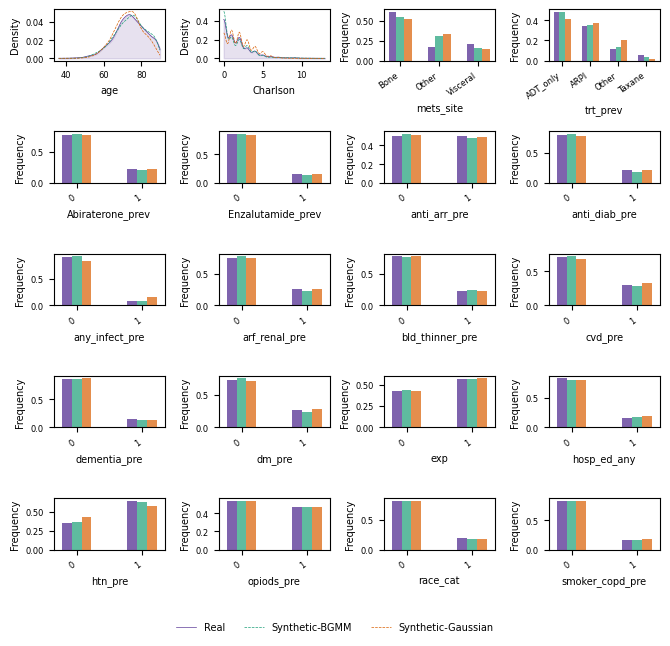

In [0]:
#cols_20 = mcrpc_data.columns.to_list()
cols_20 = numerical_var + categorical_var + binary_var
schema = DataSchema(
    numeric = numerical_var,
    binary = binary_var,
    categorical = categorical_var
)
synth_dict = {
    "Synthetic-BGMM": out1_bgmm["df_gen"],
    "Synthetic-Gaussian": out1_gauss["df_gen"]
}
plot_marginal_panel_5x4(
    real_data=mcrpc_data,
    synthetic_data=synth_dict,  # or {"Synthetic": synth_df}
    schema=schema,
    columns=cols_20,
    out_path=output_result+"m1/m1_marginals.pdf",
    sample_size=None,       # optional
)

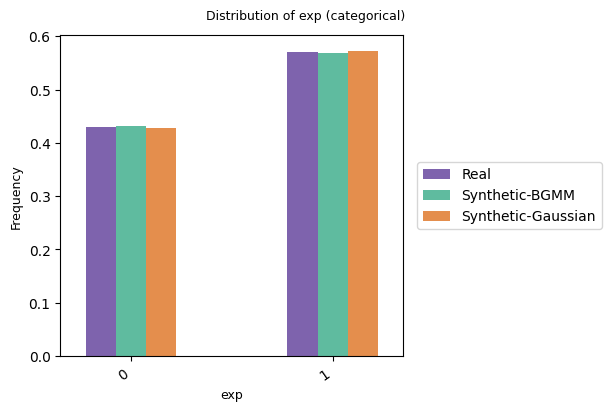

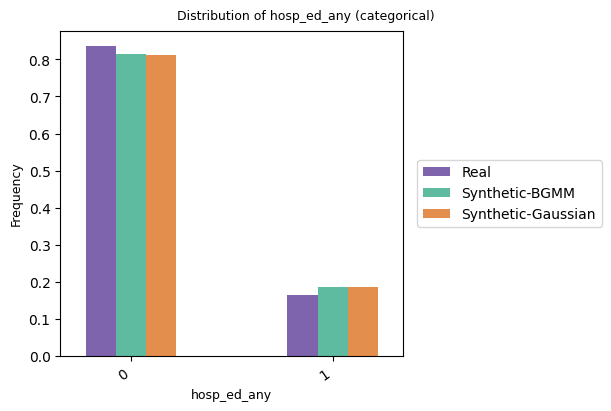

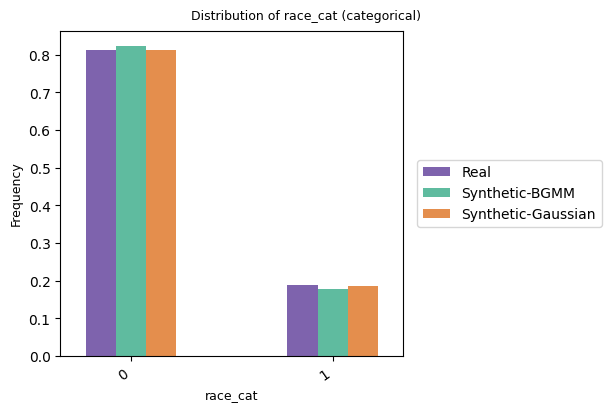

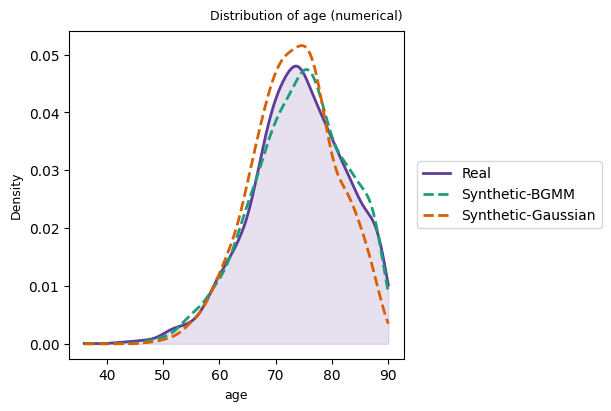

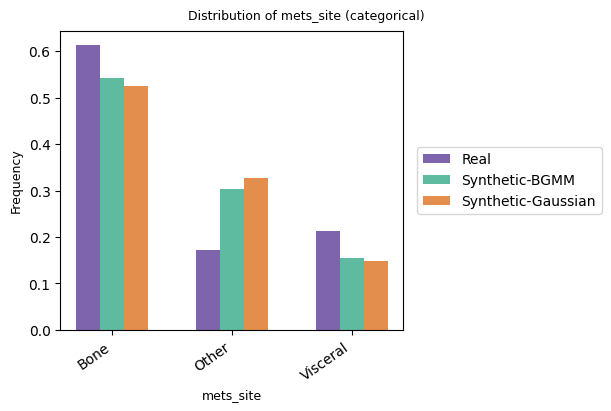

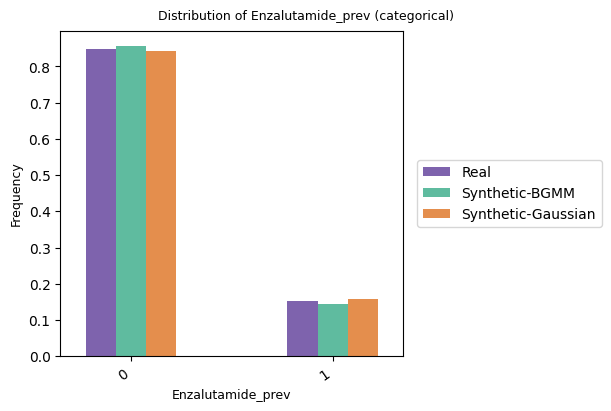

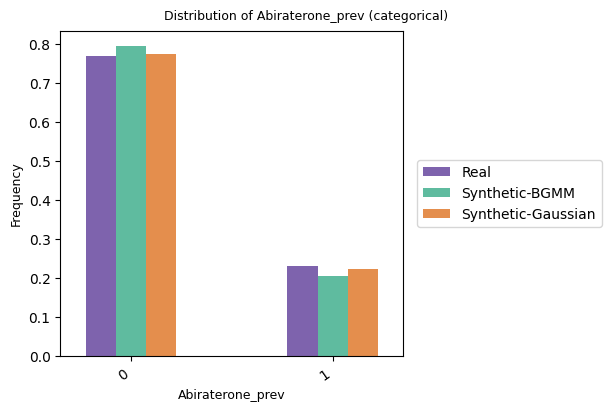

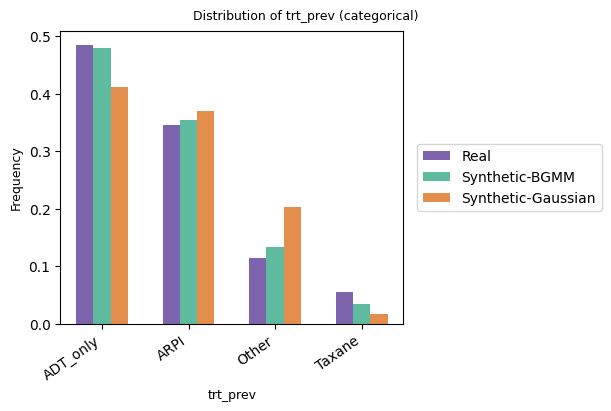

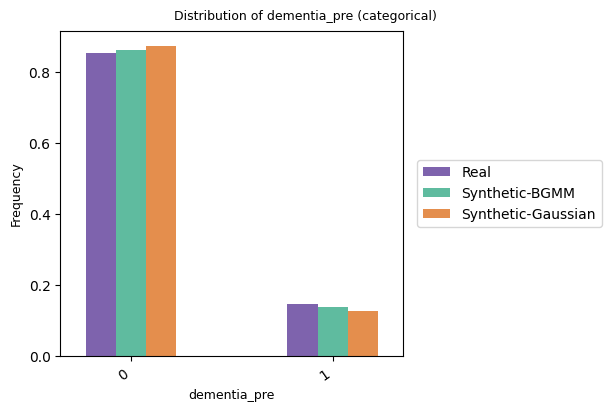

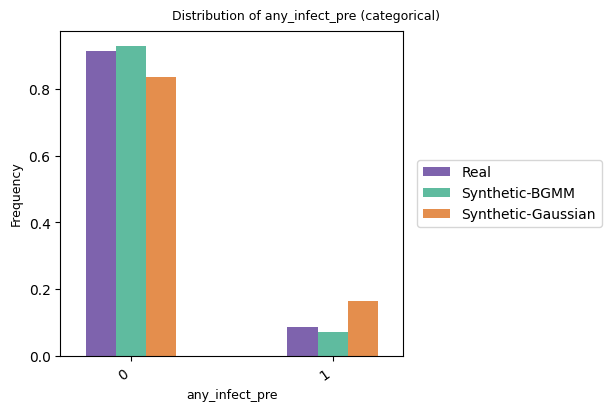

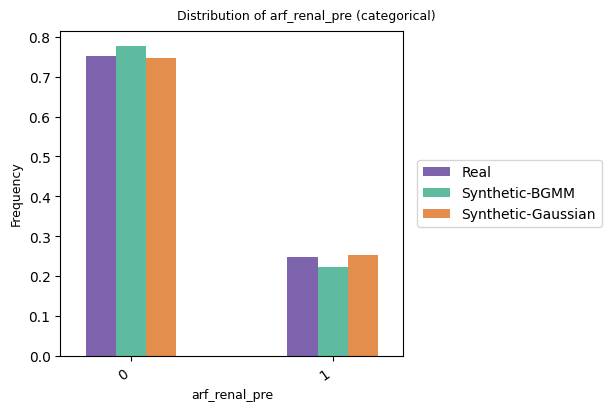

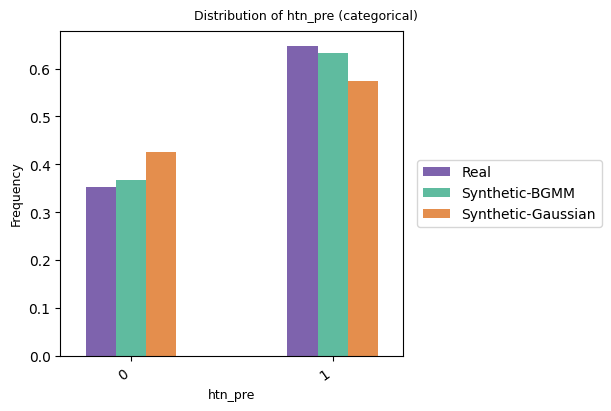

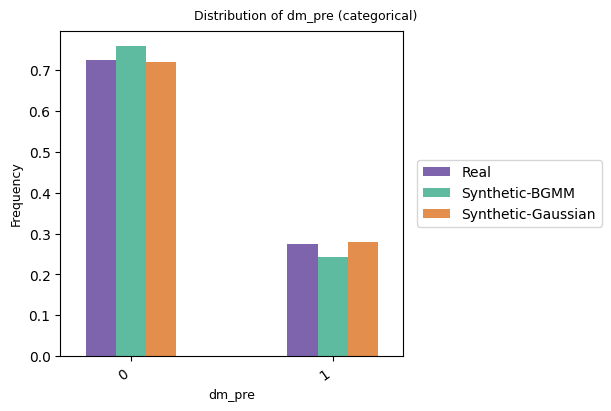

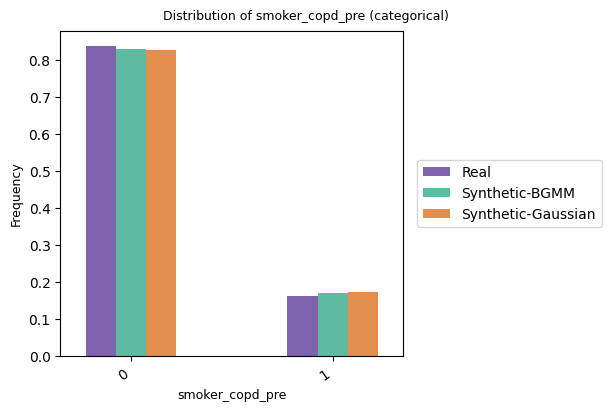

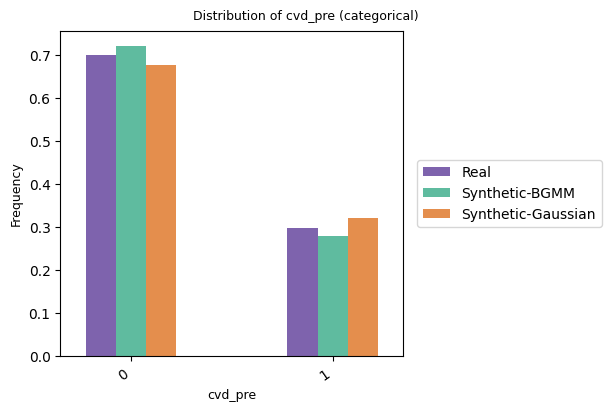

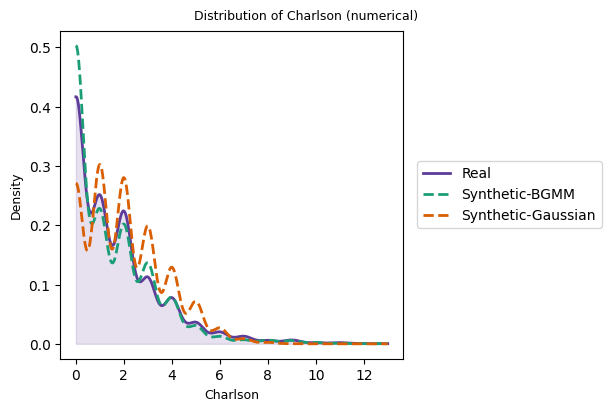

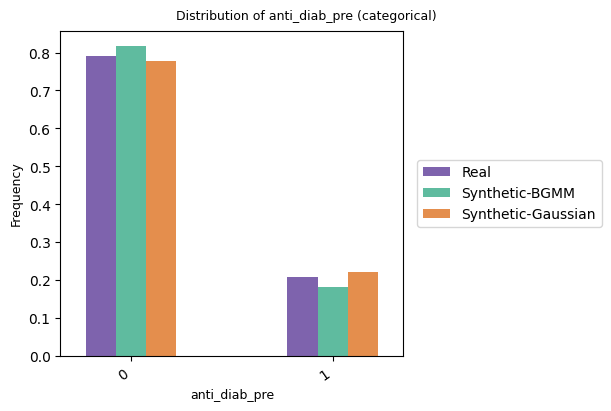

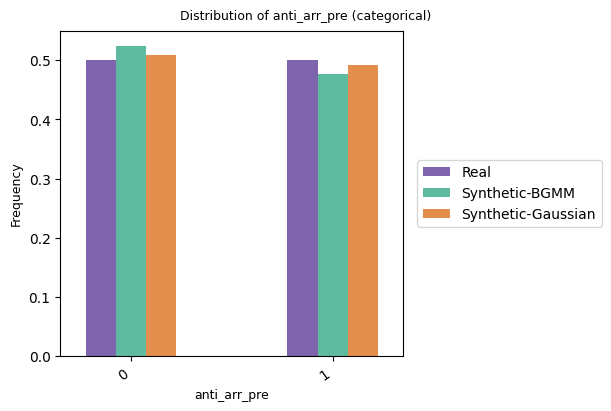

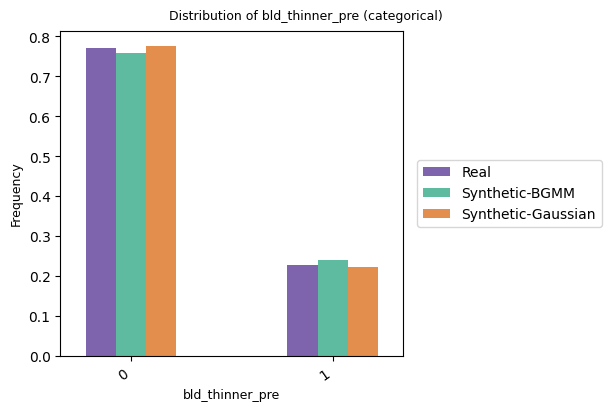

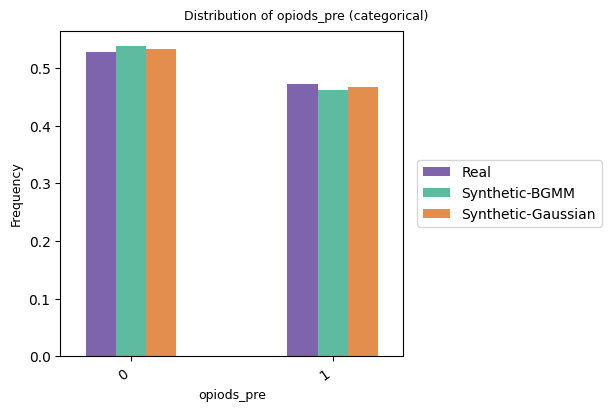

In [0]:
# Save plots for the distrbution
## including marginal plots, pariwise plots and joint plots
synth_dict = {
    "Synthetic-BGMM": out1_bgmm["df_gen"],
    "Synthetic-Gaussian": out1_gauss["df_gen"]
}
schema = DataSchema(
    numeric = numerical_var,
    binary = binary_var,
    categorical = categorical_var
)
# single column plots
for var in mcrpc_data.columns:
    fig1 = single_column_plot(
        real_data=mcrpc_data,
        synthetic_data=synth_dict,
        schema=schema,
        column_name=var,
        #main_title="Marginal distribution of age",
        x_label=var,
        y_label=None,
        fig_size=(6,4),
        legend_outside=True,
        #show_hist = True,
    )
    # save figure to pdf
    #fig.savefig(output_result + "column_" + var + ".pdf")
    fig1.show()

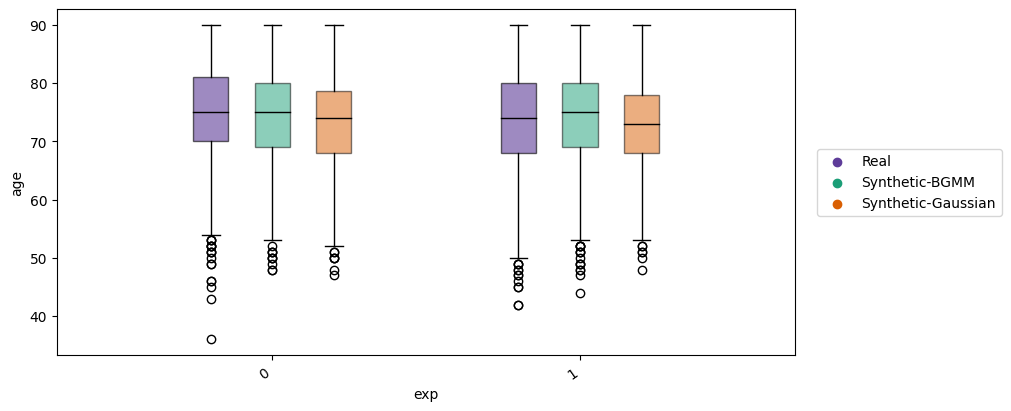

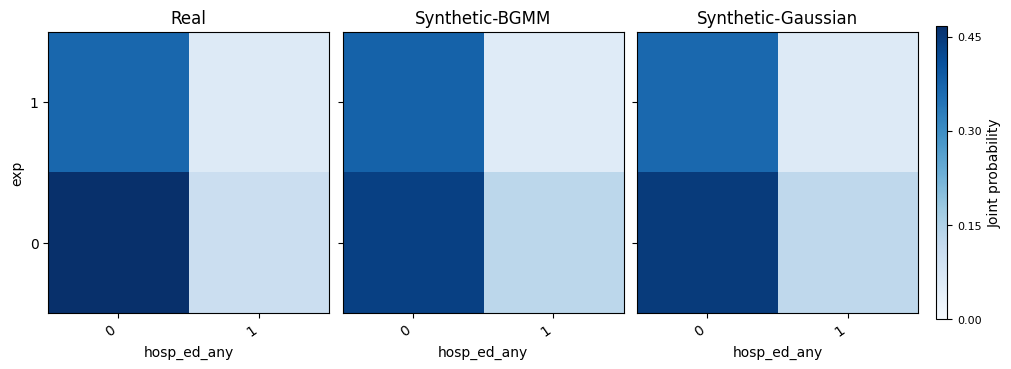

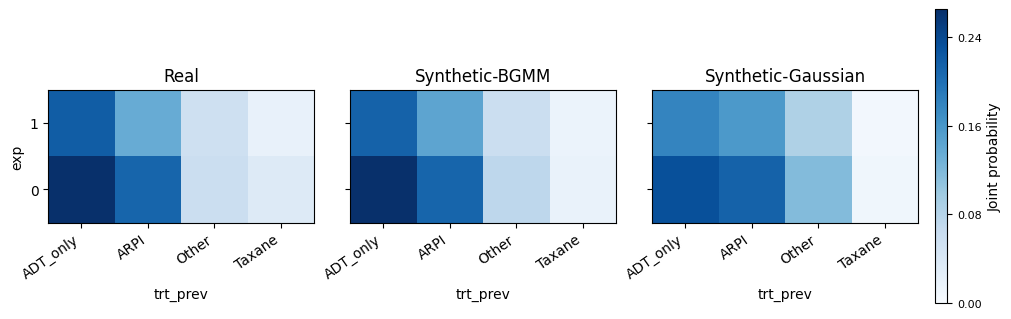

In [0]:
# pair column plots
column_names = [["exp", "age"], ["exp", "hosp_ed_any"], ["exp", "trt_prev"]]
synth_dict = {
    "Synthetic-BGMM": out1_bgmm["df_gen"],
    "Synthetic-Gaussian": out1_gauss["df_gen"]
}
for pair in column_names:
    fig2 = pair_column_plot(
        real_data=mcrpc_data,
        synthetic_data=synth_dict,
        schema=schema,
        column_names=pair,
        #main_title="Marginal distribution of age",
        add_title=False,
        x_label=None,
        y_label=None,
        fig_size=(10,4),
        legend_outside=True,
        #show_hist = True,
    )
    # save figure to pdf
    fig2.savefig(output_result + "m1/m1_" + pair[0] + "_" + pair[1] +".pdf")
    fig2.show()

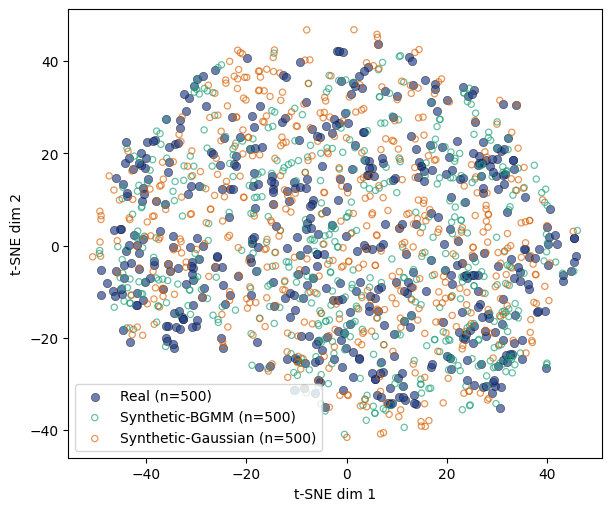

In [0]:

synth_dict = {
    "Synthetic-BGMM": out1_bgmm["df_gen"],
    "Synthetic-Gaussian": out1_gauss["df_gen"]
}

# joint distribution plot
fig3 = plot_joint_embedding_2d(
    real_df = mcrpc_data, 
    synth_df = synth_dict,
    schema = schema,
    method = "tsne",
    main_title = None,
    sample_size=500,
    legend_outside=False,
)

fig3.savefig(output_result + "m1/m1_joint.pdf")

In [0]:
# Scenario 2: linear heterogeneous treatment effect, constant small/moderate unmeasured confounding, constant small/moderate overlap

def treatment_effect_fn(X, index):
    cvd_pre, age, Charlson = index.slice(X, "cvd_pre", "age", "Charlson", unbind=True)
    out = 0.05+ 0.015 * cvd_pre + 0.01 * age + 0.01*Charlson
    return out
# works well
# weight: mse: 0.2, 0.1; var: 2e-1, 2e-2

def selection_bias_fn(X, T, index):
    # latent risk constructed from observable X
    return 0.02

def overlap_fn(X, index):
    return 1

m2 = CausalMix(
    data = mcrpc_data,  
    post_treatment_var = ["hosp_ed_any"],  
    treatment_var = ["exp"],  
    binary_var = binary_var, 
    categorical_var = categorical_var,  
    numerical_var = numerical_var,  
    integer_var = numerical_var, 
    categorical_dims=unique_levels,      
    var_bounds={},  
)

m2.fit(
    treatment_effect_fn=treatment_effect_fn,
    selection_bias_fn=selection_bias_fn,
    overlap_target=overlap_fn,
    effect_rigidity=1e3,
    effect_mse_weight=0.2, # effect blend weight on MSE
    effect_var_weight=2e-1, # variance penalty for treatment effect residuals
    bias_rigidity=1e3,
    bias_mse_weight=0.2, # bias blend weight on MSE
    bias_var_weight=2e-2, # variance penalty for bias residuals
    overlap_weight = 1e2,
    kld_rigidity=0.1
)
# Last logged validation loss from the final epoch
last_val_X = m2.m_pre.trainer.callback_metrics.get("val_loss")
print("Last val_loss for X:", float(last_val_X) if last_val_X is not None else "N/A")
last_val_Y = m2.m_post.trainer.callback_metrics.get("val_loss")
print("Last val_loss for Y:", float(last_val_Y) if last_val_Y is not None else "N/A")

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name         ┃ Type       ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ encoder      │ Sequential │  1.2 K │ train │     0 │
│ 1 │ en_mu        │ Linear     │  1.2 K │ train │     0 │
│ 2 │ en_logvar    │ Linear     │  1.2 K │ train │     0 │
│ 3 │ decoder      │ Sequential │  1.3 K │ train │     0 │
│ 4 │ output_heads │ ModuleDict │  1.5 K │ train │     0 │
│ 5 │ var_heads    │ ModuleDict │  1.2 K │ train │     0 │
└───┴──────────────┴────────────┴────────┴───────┴───────┘

Trainable params: 7.5 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 7.5 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 48                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

/local_disk0/.ephemeral_nfs/cluster_libraries/python/lib/python3.10/site-packages/pytorch_lightning/utilities/_pytree.py:21: FutureWarning:

`isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

/local_disk0/.ephemeral_nfs/cluster_libraries/python/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: PossibleUserWarning:

The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.

/local_disk0/.ephemeral_nfs/cluster_libraries/python/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: PossibleUserWarning:

The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.

GPU availab

┏━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name         ┃ Type       ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ encoder      │ Sequential │    128 │ train │     0 │
│ 1 │ en_mu        │ Linear     │    130 │ train │     0 │
│ 2 │ en_logvar    │ Linear     │    130 │ train │     0 │
│ 3 │ decoder      │ Sequential │  1.4 K │ train │     0 │
│ 4 │ output_heads │ ModuleDict │    130 │ train │     0 │
│ 5 │ var_heads    │ ModuleDict │    130 │ train │     0 │
└───┴──────────────┴────────────┴────────┴───────┴───────┘

Trainable params: 2.1 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 2.1 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 14                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

/local_disk0/.ephemeral_nfs/cluster_libraries/python/lib/python3.10/site-packages/pytorch_lightning/utilities/_pytree.py:21: FutureWarning:

`isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

/local_disk0/.ephemeral_nfs/cluster_libraries/python/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: PossibleUserWarning:

The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.

/local_disk0/.ephemeral_nfs/cluster_libraries/python/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: PossibleUserWarning:

The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.



Last val_loss for X: 1.7592990398406982
Last val_loss for Y: 0.1567123830318451


Overlap metrics: {'dec/log_ratio_mean': 0.981, 'dec/log_ratio_std': 0.059, 'dec/target_mean': 1.0, 'dec/target_std': 0.0, 'dec/mse_to_target': 0.004, 'dec/fraction_within_tol': 0.993, 'ps/auc': 0.542, 'ps/hist_overlap_coeff': 0.931, 'ps/frac_common_support': 1.0, 'ps/frac_common_support_t0': 1.0, 'ps/frac_common_support_t1': 1.0}
checking
X_np: (4098, 18)
T_np: (4098,)
tau_pred: (4098,)
kappa_pred: (4098,)
tau_target: (4098,)
kappa_target: (4098,)


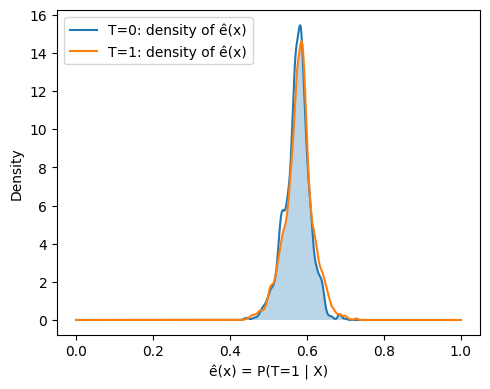

Overlap metrics: {'dec/log_ratio_mean': 0.993, 'dec/log_ratio_std': 0.072, 'dec/target_mean': 1.0, 'dec/target_std': 0.0, 'dec/mse_to_target': 0.005, 'dec/fraction_within_tol': 0.991, 'ps/auc': 0.53, 'ps/hist_overlap_coeff': 0.953, 'ps/frac_common_support': 1.0, 'ps/frac_common_support_t0': 1.0, 'ps/frac_common_support_t1': 1.0}


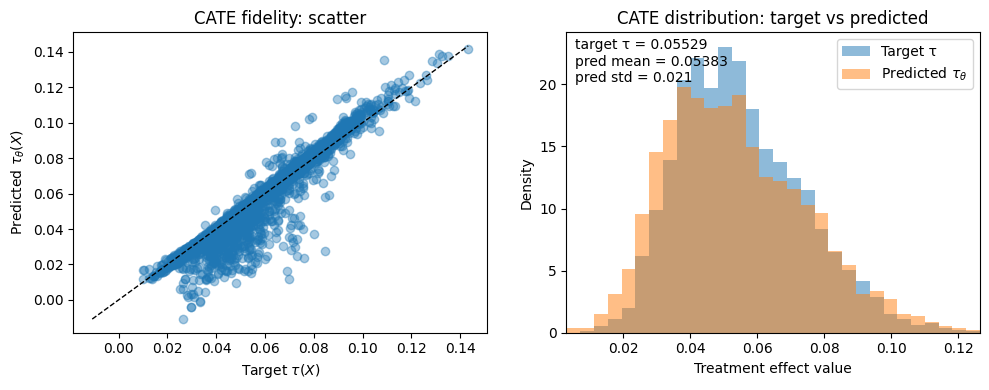

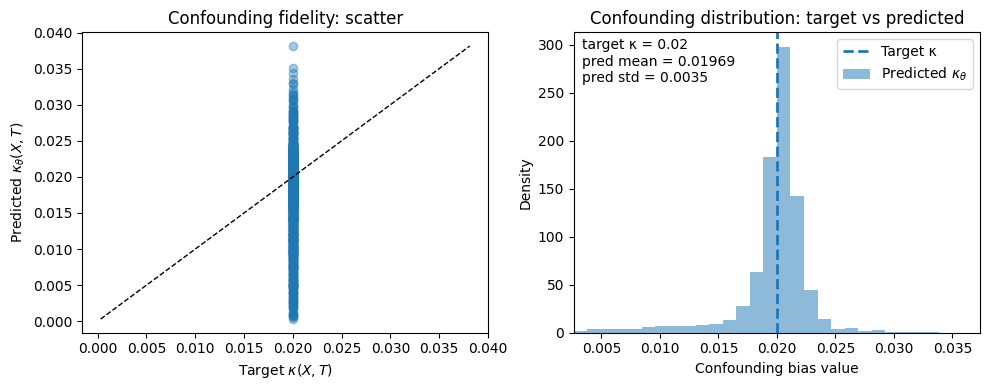

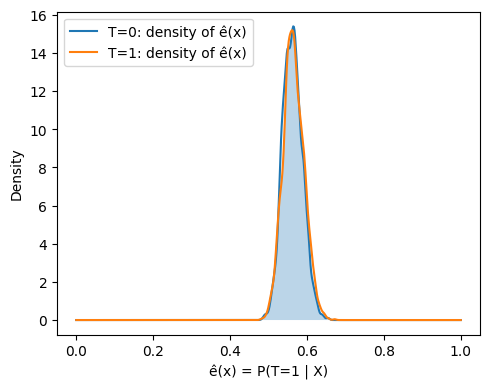

CausalEvalResults(mae_tau=0.003, corr_tau=0.953, ate_pred=0.054, ate_target=0.055, ate_abs_error=0.001, tau_wasserstein=0.002, mae_kappa=0.002, mae_kappa_t0=0.002, mae_kappa_t1=0.002, kappa_wasserstein=0.002, overlap_coeff=0.925, bw0=0.02, bw1=0.02)


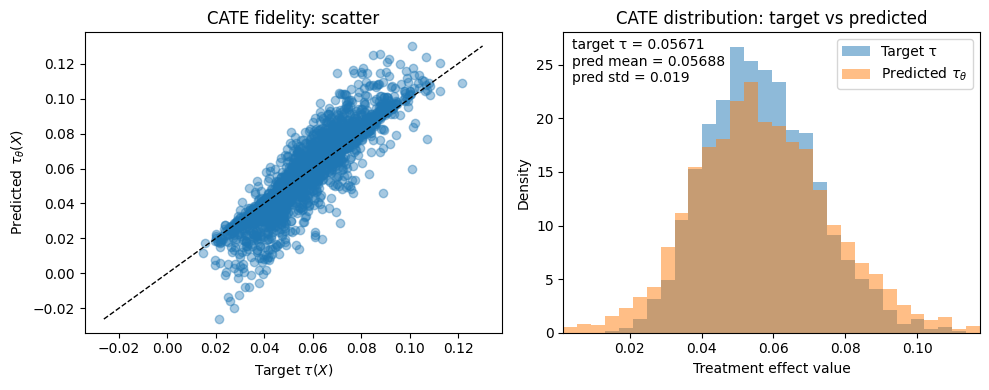

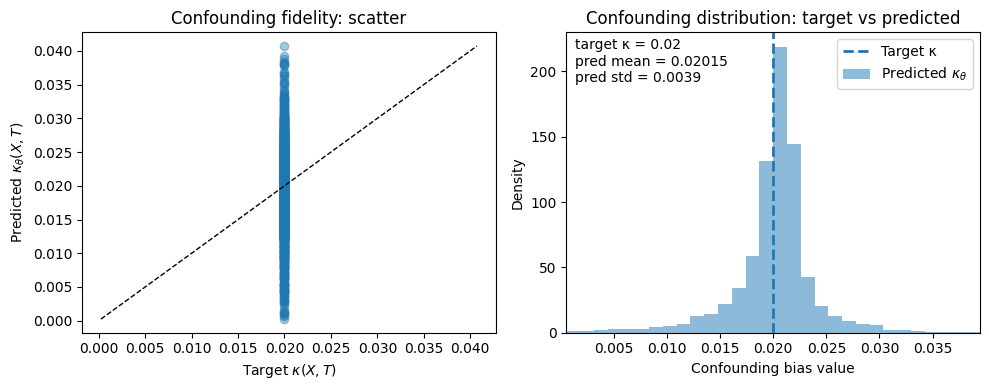

In [0]:
# Scenario 2
# generate new samples and return causal evaluation metrics
out2_bgmm = m2.causal_bgmm(
    n_samples=mcrpc_data.shape[0],
    deterministic=False,
    return_probs=False,
    plot=True,
    savepath=output_result+"m2/m2_bgmm_"
)
out2_gauss = m2.causal_gauss(
    n_samples=mcrpc_data.shape[0],
    deterministic=False,
    return_probs=False,
    plot=True,
    savepath=output_result+"m2/m2_gauss_"
)

cm_metrics = out2_bgmm["causal_metrics"]
print(cm_metrics)

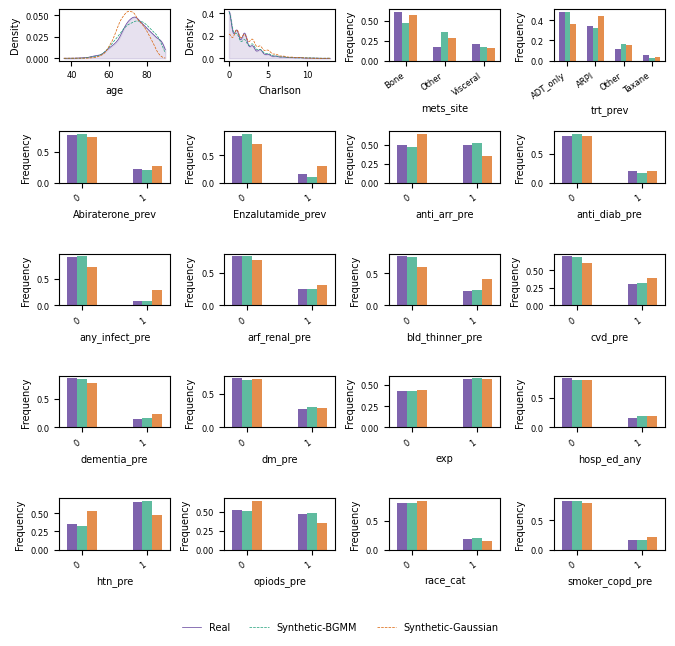

'\n# overlap evaluation class\n# This class was moved to the causal_eval\nimport numpy as np\nimport torch\nimport torch.nn.functional as F\nimport matplotlib.pyplot as plt\n\n# ---------- helpers ----------\n\ndef fit_logistic_torch(X_np, T_np, max_iter=200):\n    \'\'\'Torch logistic regression; returns e_hat = sigmoid(X @ w + b).\'\'\'\n    X = torch.from_numpy(np.asarray(X_np, np.float32))\n    t = torch.from_numpy(np.asarray(T_np, np.float32))\n\n    # Use CPU by default; switch to GPU if desired\n    device = torch.device("cpu")\n    X = X.to(device); t = t.to(device)\n\n    w = torch.zeros(X.size(1), 1, device=device, requires_grad=True)\n    b = torch.zeros(1, device=device, requires_grad=True)\n    opt = torch.optim.LBFGS([w, b], max_iter=max_iter, tolerance_grad=1e-8, tolerance_change=1e-9)\n\n    def closure():\n        opt.zero_grad()\n        logits = X @ w + b\n        loss = F.binary_cross_entropy_with_logits(logits.squeeze(1), t)\n        loss.backward()\n        return

In [0]:
cols_20 = numerical_var + categorical_var + binary_var
schema = DataSchema(
    numeric = numerical_var,
    binary = binary_var,
    categorical = categorical_var
)
synth_dict = {
    "Synthetic-BGMM": out2_bgmm["df_gen"],
    "Synthetic-Gaussian": out2_gauss["df_gen"]
}
plot_marginal_panel_5x4(
    real_data=mcrpc_data,
    synthetic_data=synth_dict,  # or {"Synthetic": synth_df}
    schema=schema,
    columns=cols_20,
    out_path=output_result+"m2/m2_marginals.pdf",
    sample_size=None,       # optional
)

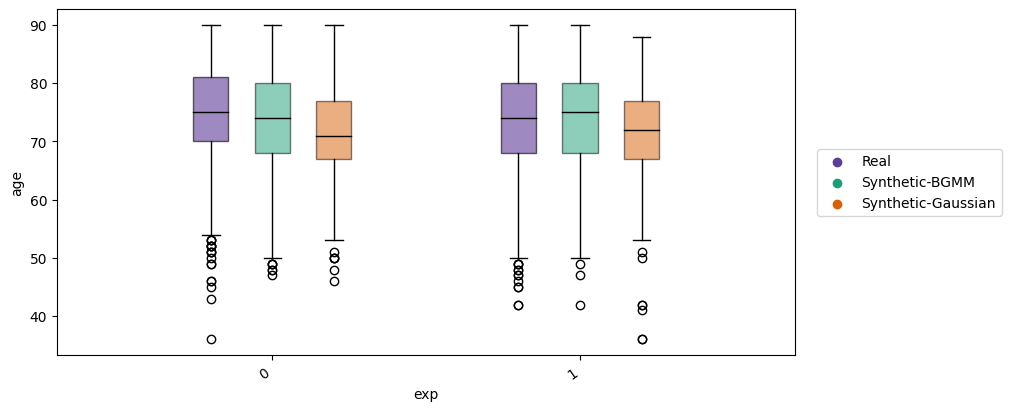

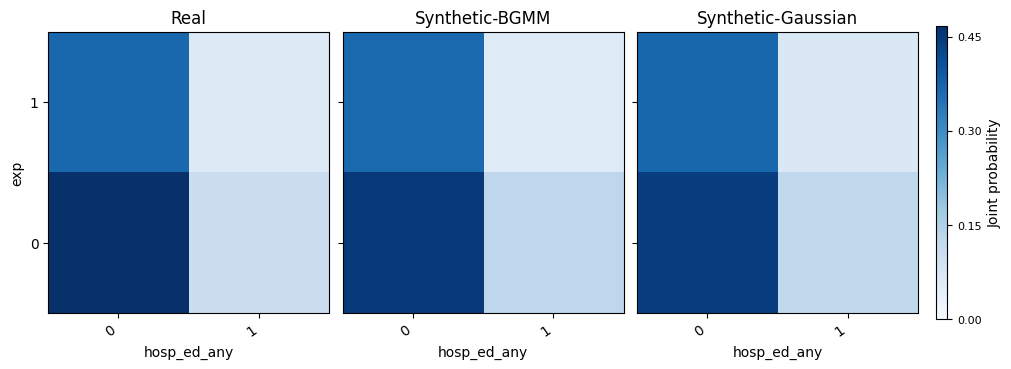

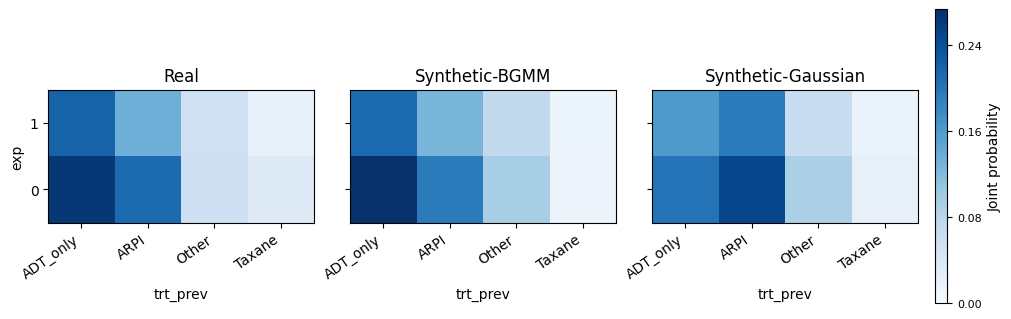

In [0]:
# pair column plots
column_names = [["exp", "age"], ["exp", "hosp_ed_any"], ["exp", "trt_prev"]]
synth_dict = {
    "Synthetic-BGMM": out2_bgmm["df_gen"],
    "Synthetic-Gaussian": out2_gauss["df_gen"]
}
for pair in column_names:
    fig2 = pair_column_plot(
        real_data=mcrpc_data,
        synthetic_data=synth_dict,
        schema=schema,
        column_names=pair,
        #main_title="Marginal distribution of age",
        add_title=False,
        x_label=None,
        y_label=None,
        fig_size=(10,4),
        legend_outside=True,
        #show_hist = True,
    )
    # save figure to pdf
    fig2.savefig(output_result + "m2/m2_" + pair[0] + "_" + pair[1] +".pdf")
    fig2.show()

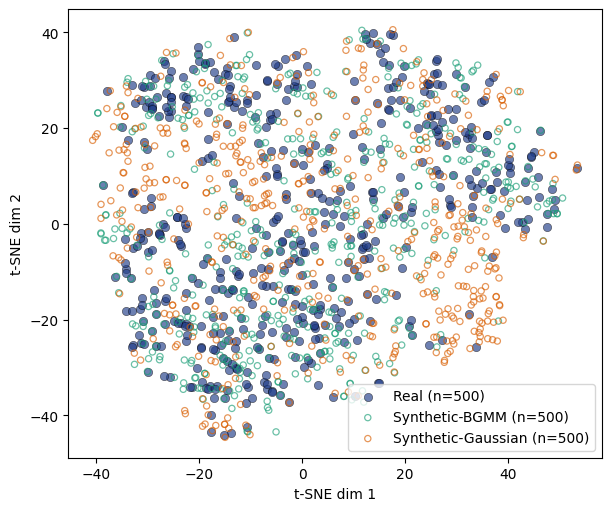

In [0]:
synth_dict = {
    "Synthetic-BGMM": out2_bgmm["df_gen"],
    "Synthetic-Gaussian": out2_gauss["df_gen"]
}
schema = DataSchema(
    numeric = numerical_var,
    binary = binary_var,
    categorical = categorical_var
)
# joint distribution plot
fig3 = plot_joint_embedding_2d(
    real_df = mcrpc_data, 
    synth_df = synth_dict,
    schema = schema,
    method = "tsne",
    sample_size = 500,
    main_title = None,
    legend_outside=False
)

fig3.savefig(output_result + "m2/m2_joint.pdf")

In [0]:
# scenario 3 rerun, scenario 1, 2 okay
# Scenario 3: nonlinear heterogeneous treatment effect, unmeasured confounding function, moderate overlap function
def treatment_effect_fn(X, index):
    cvd_pre, age, Charlson, dementia_pre = index.slice(X, "cvd_pre", "age", "Charlson", "dementia_pre", unbind=True)
    # X is a torch.Tensor of features excluding 
    return 0.02 + 0.05*torch.tanh(0.4*cvd_pre + 0.2*age + 0.2*Charlson + 0.4*dementia_pre) #+ Charlson
    # mse weight: 03-0.4, 0.1-0.2; var weight: 2e-1, 2e-2


def selection_bias_fn(X, T, index):
    # latent risk constructed from observable X
    cvd_pre, age, Charlson= index.slice(X, "cvd_pre", "age",  "Charlson", unbind=True)
    U = 0.5*Charlson + 0.6*cvd_pre + 0.2*age
    return 0.05-0.01*(2*T-1)*torch.tanh(U)


def overlap_fn(X, index):
    Abiraterone_prev = index.slice(X, "Abiraterone_prev")
    return 2*(2*Abiraterone_prev-1)

m3 = CausalMix(
    data = mcrpc_data,  
    post_treatment_var = ["hosp_ed_any"],  
    treatment_var = ["exp"],  
    binary_var = binary_var, 
    categorical_var = categorical_var,  
    numerical_var = numerical_var,  
    integer_var = numerical_var, 
    categorical_dims=unique_levels,      
    var_bounds={},  
)

m3.fit(
    treatment_effect_fn=treatment_effect_fn,
    selection_bias_fn=selection_bias_fn,
    overlap_target=overlap_fn,
    effect_rigidity=1e3,
    effect_mse_weight=0.4, # effect blend weight on MSE
    effect_var_weight=2e-1, # variance penalty for treatment effect residuals
    bias_rigidity=1e3,
    bias_mse_weight=0.2, # bias blend weight on MSE 
    bias_var_weight=2e-2, # variance penalty for bias residuals #2e-2
    overlap_weight = 1e1,
    kld_rigidity=0.1
)

# Last logged validation loss from the final epoch
last_val_X = m3.m_pre.trainer.callback_metrics.get("val_loss")
print("Last val_loss for X:", float(last_val_X) if last_val_X is not None else "N/A")
last_val_Y = m3.m_post.trainer.callback_metrics.get("val_loss")
print("Last val_loss for Y:", float(last_val_Y) if last_val_Y is not None else "N/A")

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name         ┃ Type       ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ encoder      │ Sequential │  1.2 K │ train │     0 │
│ 1 │ en_mu        │ Linear     │  1.2 K │ train │     0 │
│ 2 │ en_logvar    │ Linear     │  1.2 K │ train │     0 │
│ 3 │ decoder      │ Sequential │  1.3 K │ train │     0 │
│ 4 │ output_heads │ ModuleDict │  1.5 K │ train │     0 │
│ 5 │ var_heads    │ ModuleDict │  1.2 K │ train │     0 │
└───┴──────────────┴────────────┴────────┴───────┴───────┘

Trainable params: 7.5 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 7.5 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 48                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

/local_disk0/.ephemeral_nfs/cluster_libraries/python/lib/python3.10/site-packages/pytorch_lightning/utilities/_pytree.py:21: FutureWarning:

`isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

/local_disk0/.ephemeral_nfs/cluster_libraries/python/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: PossibleUserWarning:

The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.

/local_disk0/.ephemeral_nfs/cluster_libraries/python/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: PossibleUserWarning:

The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.

INFO:pytorc

┏━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name         ┃ Type       ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ encoder      │ Sequential │    128 │ train │     0 │
│ 1 │ en_mu        │ Linear     │    130 │ train │     0 │
│ 2 │ en_logvar    │ Linear     │    130 │ train │     0 │
│ 3 │ decoder      │ Sequential │  1.4 K │ train │     0 │
│ 4 │ output_heads │ ModuleDict │    130 │ train │     0 │
│ 5 │ var_heads    │ ModuleDict │    130 │ train │     0 │
└───┴──────────────┴────────────┴────────┴───────┴───────┘

Trainable params: 2.1 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 2.1 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 14                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

/local_disk0/.ephemeral_nfs/cluster_libraries/python/lib/python3.10/site-packages/pytorch_lightning/utilities/_pytree.py:21: FutureWarning:

`isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

/local_disk0/.ephemeral_nfs/cluster_libraries/python/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: PossibleUserWarning:

The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.

/local_disk0/.ephemeral_nfs/cluster_libraries/python/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: PossibleUserWarning:

The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.



Last val_loss for X: 1.5691759586334229
Last val_loss for Y: 0.16966305673122406


Overlap metrics: {'dec/log_ratio_mean': -0.255, 'dec/log_ratio_std': 1.965, 'dec/target_mean': -0.225, 'dec/target_std': 1.987, 'dec/mse_to_target': 0.003, 'dec/fraction_within_tol': 1.0, 'ps/auc': 0.892, 'ps/hist_overlap_coeff': 0.235, 'ps/frac_common_support': 1.0, 'ps/frac_common_support_t0': 1.0, 'ps/frac_common_support_t1': 1.0}
checking
X_np: (4098, 18)
T_np: (4098,)
tau_pred: (4098,)
kappa_pred: (4098,)
tau_target: (4098,)
kappa_target: (4098,)


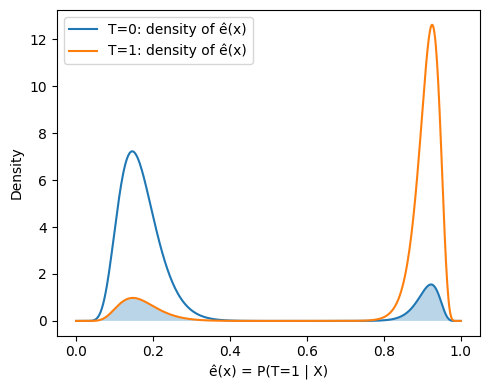

Overlap metrics: {'dec/log_ratio_mean': -0.027, 'dec/log_ratio_std': 1.971, 'dec/target_mean': 0.007, 'dec/target_std': 2.0, 'dec/mse_to_target': 0.006, 'dec/fraction_within_tol': 0.993, 'ps/auc': 0.813, 'ps/hist_overlap_coeff': 0.397, 'ps/frac_common_support': 1.0, 'ps/frac_common_support_t0': 1.0, 'ps/frac_common_support_t1': 1.0}


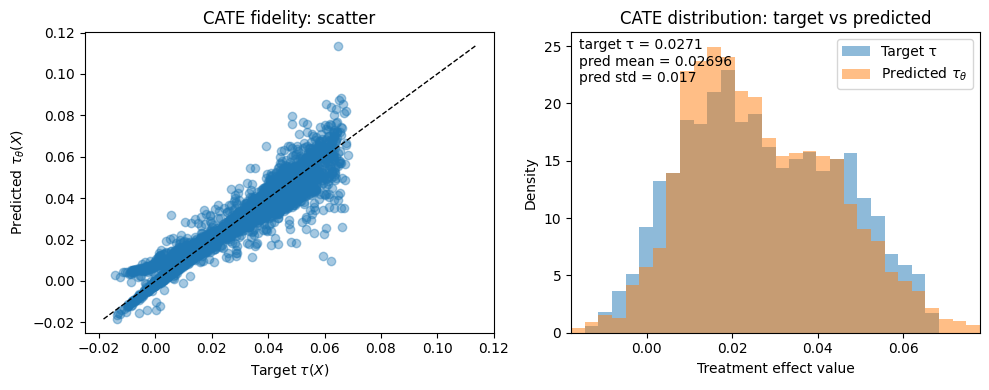

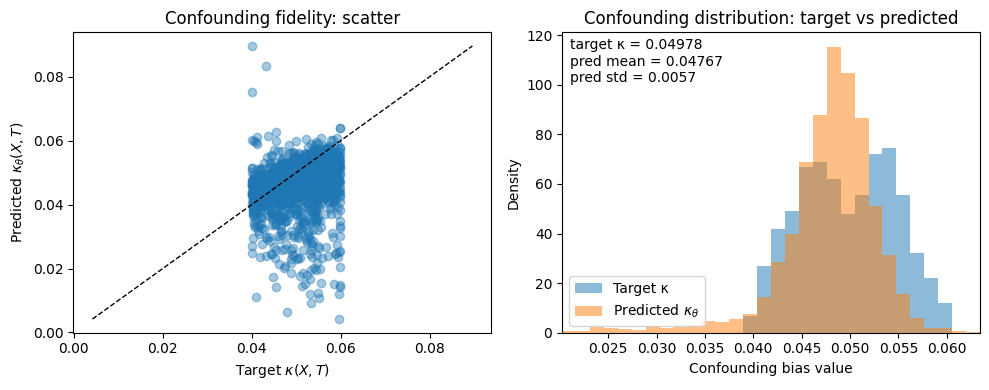

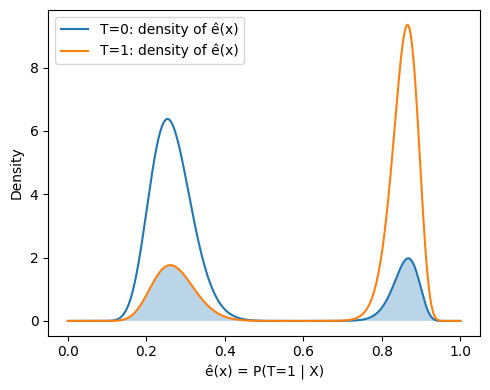

CausalEvalResults(mae_tau=0.004, corr_tau=0.947, ate_pred=0.027, ate_target=0.027, ate_abs_error=0.0, tau_wasserstein=0.001, mae_kappa=0.004, mae_kappa_t0=0.005, mae_kappa_t1=0.003, kappa_wasserstein=0.002, overlap_coeff=0.235, bw0=0.345, bw1=0.345)


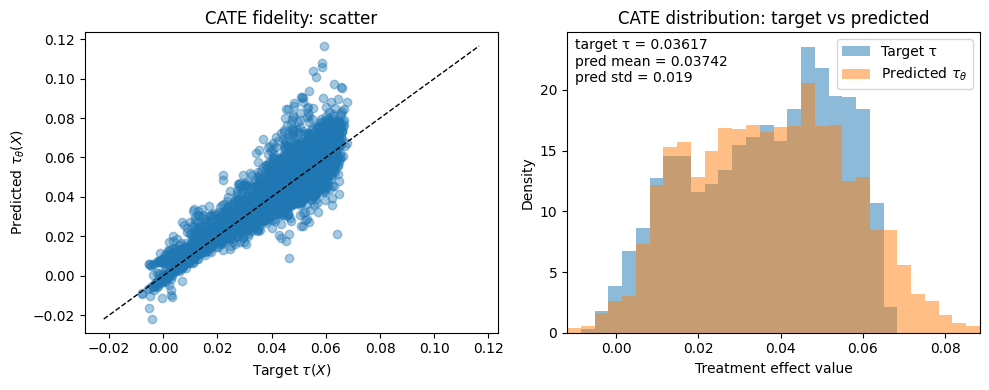

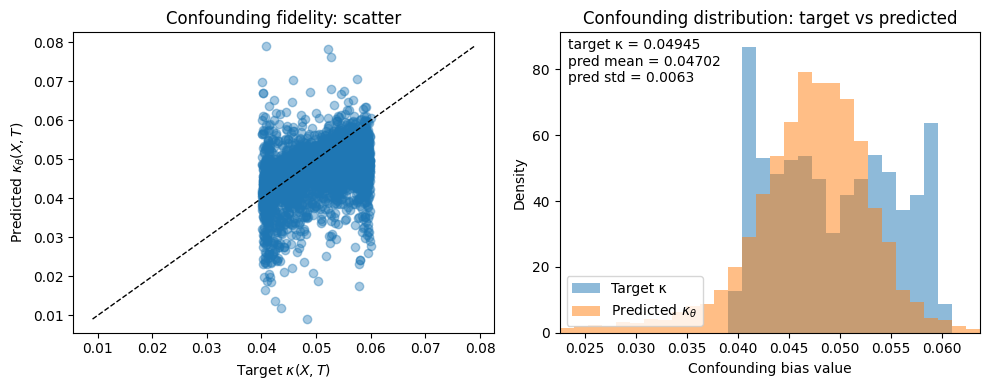

In [0]:
out3_bgmm = m3.causal_bgmm(
    n_samples=mcrpc_data.shape[0],
    deterministic=False,
    return_probs=False,
    plot=True,
    savepath=output_result+"m3/m3_bgmm_"
)
out3_gauss = m3.causal_gauss(
    n_samples=mcrpc_data.shape[0],
    deterministic=False,
    return_probs=False,
    plot=True,
    savepath=output_result+"m3/m3_gauss_"
)

cm_metrics = out3_bgmm["causal_metrics"]
print(cm_metrics)

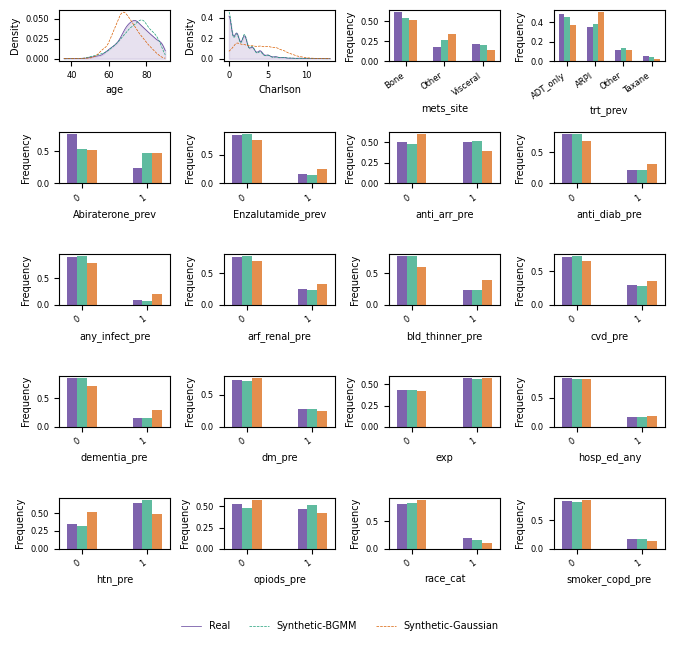

In [0]:
cols_20 = numerical_var + categorical_var + binary_var
schema = DataSchema(
    numeric = numerical_var,
    binary = binary_var,
    categorical = categorical_var
)
synth_dict = {
    "Synthetic-BGMM": out3_bgmm["df_gen"],
    "Synthetic-Gaussian": out3_gauss["df_gen"]
}
plot_marginal_panel_5x4(
    real_data=mcrpc_data,
    synthetic_data=synth_dict,  # or {"Synthetic": synth_df}
    schema=schema,
    columns=cols_20,
    out_path=output_result+"m3/m3_marginals.pdf",
    sample_size=None,       # optional
)

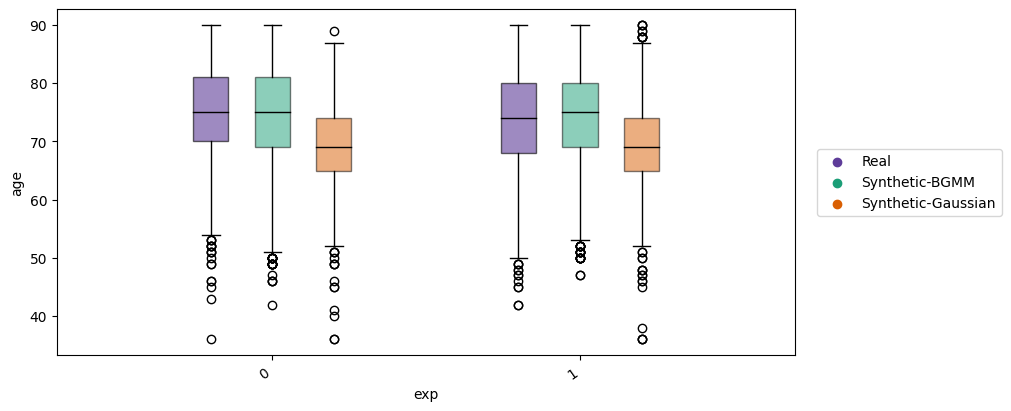

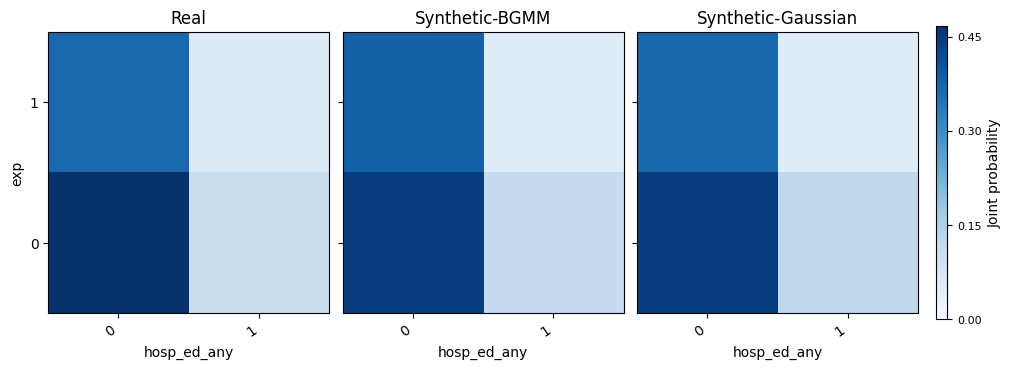

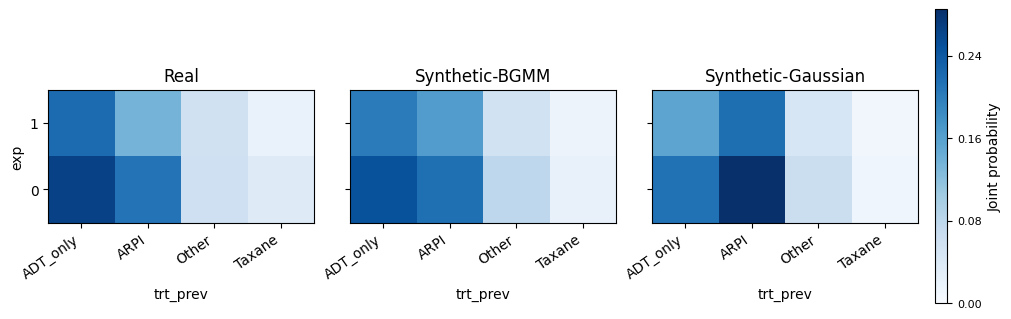

In [0]:
# pair column plots
column_names = [["exp", "age"], ["exp", "hosp_ed_any"], ["exp", "trt_prev"]]
synth_dict = {
    "Synthetic-BGMM": out3_bgmm["df_gen"],
    "Synthetic-Gaussian": out3_gauss["df_gen"]
}
for pair in column_names:
    fig2 = pair_column_plot(
        real_data=mcrpc_data,
        synthetic_data=synth_dict,
        schema=schema,
        column_names=pair,
        #main_title="Marginal distribution of age",
        add_title=False,
        x_label=None,
        y_label=None,
        fig_size=(10,4),
        legend_outside=True,
        #show_hist = True,
    )
    # save figure to pdf
    fig2.savefig(output_result + "m3/m3_" + pair[0] + "_" + pair[1] +".pdf")
    fig2.show()

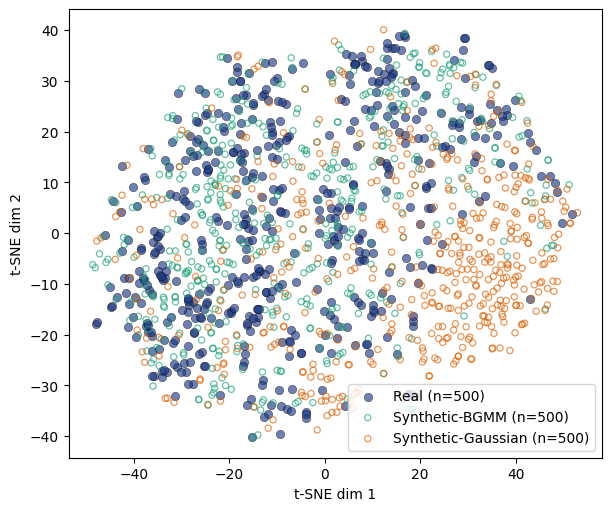

In [0]:
synth_dict = {
    "Synthetic-BGMM": out3_bgmm["df_gen"],
    "Synthetic-Gaussian": out3_gauss["df_gen"]
}

# joint distribution plot
fig3 = plot_joint_embedding_2d(
    real_df = mcrpc_data, 
    synth_df = synth_dict,
    schema = schema,
    method = "tsne",
    sample_size = 500,
    main_title = None,
    legend_outside=False
)

fig3.savefig(output_result + "m3/m3_joint.pdf")